In [1]:
# ============================================================
# Cell 1: Imports, Paths, Data, and Ensemble Weights
# ============================================================

from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")


# ============================================================
# Paths
# ============================================================

PROCESSED_DATA_DIR = Path("../Data/Processed")
MODEL_DIR = Path("../Models")
RESULTS_DIR = Path("../Results")

PREPROCESSOR_PATH = (
    PROCESSED_DATA_DIR
    / "preprocessing_metadata.pkl"
)

PREDICTIONS_PATH = (
    RESULTS_DIR
    / "test_predictions.npz"
)

TFT_MODEL_PATH = (
    MODEL_DIR
    / "tft_model.pth"
)

PATCHTST_MODEL_PATH = (
    MODEL_DIR
    / "patchtst_model.pth"
)

ENSEMBLE_MODEL_PATH = (
    MODEL_DIR
    / "ensemble_model.pkl"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Validate Required Files
# ============================================================

required_files = [
    PREPROCESSOR_PATH,
    PREDICTIONS_PATH,
    TFT_MODEL_PATH,
    PATCHTST_MODEL_PATH,
]

for path in required_files:

    if not path.exists():

        raise FileNotFoundError(
            f"Required file not found: {path}"
        )


# ============================================================
# Load Metadata
# ============================================================

with open(
    PREPROCESSOR_PATH,
    "rb",
) as file:

    metadata = pickle.load(file)


TARGET_COLUMNS = metadata[
    "target_columns"
]

PREDICTION_LENGTH = metadata[
    "prediction_length"
]

NUM_TARGETS = len(
    TARGET_COLUMNS
)


# ============================================================
# Load Test Predictions from Notebook 08
# ============================================================

prediction_data = np.load(
    PREDICTIONS_PATH
)

y_true = prediction_data[
    "y_true"
].astype(np.float32)

tft_pred = prediction_data[
    "tft_pred"
].astype(np.float32)

patchtst_pred = prediction_data[
    "patchtst_pred"
].astype(np.float32)


if not (
    y_true.shape
    == tft_pred.shape
    == patchtst_pred.shape
):

    raise ValueError(
        "Prediction shapes do not match."
    )


if not (
    np.isfinite(y_true).all()
    and np.isfinite(tft_pred).all()
    and np.isfinite(patchtst_pred).all()
):

    raise ValueError(
        "Predictions contain NaN or Inf."
    )


# ============================================================
# Load Model Checkpoints
# ============================================================

tft_checkpoint = torch.load(
    TFT_MODEL_PATH,
    map_location="cpu",
)

patchtst_checkpoint = torch.load(
    PATCHTST_MODEL_PATH,
    map_location="cpu",
)


# ============================================================
# Extract Validation MAE
# ============================================================

def extract_validation_mae(
    checkpoint,
    model_name,
):

    possible_keys = [
        "validation_mae",
        "val_mae",
        "best_val_mae",
    ]

    for key in possible_keys:

        if key in checkpoint:

            value = np.asarray(
                checkpoint[key],
                dtype=np.float64,
            )

            if (
                value.ndim == 1
                and len(value) == NUM_TARGETS
            ):

                return value


    print(
        f"{model_name}: pollutant-wise "
        "validation MAE not found."
    )

    return None


tft_val_mae = extract_validation_mae(
    tft_checkpoint,
    "TFT",
)

patchtst_val_mae = extract_validation_mae(
    patchtst_checkpoint,
    "PatchTST",
)


# ============================================================
# Validation-Based Ensemble Weights
# ============================================================

if (
    tft_val_mae is not None
    and patchtst_val_mae is not None
):

    epsilon = 1e-8

    tft_inverse = (
        1.0
        / (
            tft_val_mae
            + epsilon
        )
    )

    patch_inverse = (
        1.0
        / (
            patchtst_val_mae
            + epsilon
        )
    )

    total_inverse = (
        tft_inverse
        + patch_inverse
    )

    tft_weights = (
        tft_inverse
        / total_inverse
    )

    patchtst_weights = (
        patch_inverse
        / total_inverse
    )

    WEIGHT_SOURCE = (
        "pollutant-wise validation MAE"
    )

else:

    tft_weights = np.full(
        NUM_TARGETS,
        0.5,
        dtype=np.float64,
    )

    patchtst_weights = np.full(
        NUM_TARGETS,
        0.5,
        dtype=np.float64,
    )

    WEIGHT_SOURCE = (
        "equal-weight fallback"
    )


ensemble_weights = pd.DataFrame({
    "Pollutant": TARGET_COLUMNS,
    "TFT_Weight": tft_weights,
    "PatchTST_Weight": patchtst_weights,
})


print("=" * 65)
print("ENSEMBLE CONFIGURATION")
print("=" * 65)

print(
    f"Prediction shape  : "
    f"{y_true.shape}"
)

print(
    f"Targets           : "
    f"{NUM_TARGETS}"
)

print(
    f"Forecast horizon  : "
    f"{PREDICTION_LENGTH} hours"
)

print(
    f"Weight source     : "
    f"{WEIGHT_SOURCE}"
)

print(
    "\nEnsemble Weights"
)

display(
    ensemble_weights.round(4)
)

TFT: pollutant-wise validation MAE not found.
PatchTST: pollutant-wise validation MAE not found.
ENSEMBLE CONFIGURATION
Prediction shape  : (479204, 15, 9)
Targets           : 9
Forecast horizon  : 15 hours
Weight source     : equal-weight fallback

Ensemble Weights


,Pollutant,TFT_Weight,PatchTST_Weight
0,pm2_5,0.5,0.5
1,pm10,0.5,0.5
2,no,0.5,0.5
3,no2,0.5,0.5
4,nox,0.5,0.5
5,nh3,0.5,0.5
6,co,0.5,0.5
7,so2,0.5,0.5
8,o3,0.5,0.5


In [2]:
# ============================================================
# Cell 2: Ensemble Prediction, Evaluation, and Saving
# ============================================================

# ============================================================
# Create Weighted Ensemble
# ============================================================

tft_weight_array = (
    tft_weights
    .reshape(
        1,
        1,
        NUM_TARGETS,
    )
)

patchtst_weight_array = (
    patchtst_weights
    .reshape(
        1,
        1,
        NUM_TARGETS,
    )
)


ensemble_pred = (
    tft_pred
    * tft_weight_array
    + patchtst_pred
    * patchtst_weight_array
).astype(np.float32)


if not np.isfinite(
    ensemble_pred
).all():

    raise ValueError(
        "Ensemble predictions contain "
        "NaN or Inf."
    )


# ============================================================
# Metrics
# ============================================================

def smape(
    y_true,
    y_pred,
):

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    return 100 * np.mean(
        np.divide(
            2 * np.abs(
                y_pred - y_true
            ),
            denominator,
            out=np.zeros_like(
                denominator,
                dtype=np.float64,
            ),
            where=denominator != 0,
        )
    )


def calculate_metrics(
    y_true,
    y_pred,
):

    true_flat = y_true.reshape(-1)
    pred_flat = y_pred.reshape(-1)

    return {
        "MAE": mean_absolute_error(
            true_flat,
            pred_flat,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                true_flat,
                pred_flat,
            )
        ),
        "R2": r2_score(
            true_flat,
            pred_flat,
        ),
        "sMAPE": smape(
            true_flat,
            pred_flat,
        ),
    }


# ============================================================
# Overall Model Comparison
# ============================================================

model_predictions = {
    "TFT": tft_pred,
    "PatchTST": patchtst_pred,
    "Ensemble": ensemble_pred,
}


overall_results = pd.DataFrame({
    model_name: calculate_metrics(
        y_true,
        prediction,
    )
    for model_name, prediction
    in model_predictions.items()
}).T

overall_results.index.name = "Model"


# ============================================================
# Pollutant-Wise Ensemble Metrics
# ============================================================

pollutant_records = []

for model_name, prediction in (
    model_predictions.items()
):

    for (
        target_index,
        target,
    ) in enumerate(
        TARGET_COLUMNS
    ):

        metrics = calculate_metrics(
            y_true[
                :,
                :,
                target_index,
            ],
            prediction[
                :,
                :,
                target_index,
            ],
        )

        pollutant_records.append({
            "Model": model_name,
            "Pollutant": target,
            **metrics,
        })


pollutant_results = pd.DataFrame(
    pollutant_records
)


# ============================================================
# Forecast Horizon Metrics
# ============================================================

horizon_records = []

for model_name, prediction in (
    model_predictions.items()
):

    for horizon in range(
        PREDICTION_LENGTH
    ):

        metrics = calculate_metrics(
            y_true[
                :,
                horizon,
                :,
            ],
            prediction[
                :,
                horizon,
                :,
            ],
        )

        horizon_records.append({
            "Model": model_name,
            "Forecast_Hour": (
                horizon + 1
            ),
            **metrics,
        })


horizon_results = pd.DataFrame(
    horizon_records
)


# ============================================================
# Save Ensemble Configuration
# ============================================================

ensemble_artifact = {
    "ensemble_type": (
        "validation_mae_weighted_average"
    ),
    "weight_source": WEIGHT_SOURCE,
    "target_columns": TARGET_COLUMNS,
    "prediction_length": PREDICTION_LENGTH,
    "tft_weights": (
        tft_weights.astype(
            np.float32
        )
    ),
    "patchtst_weights": (
        patchtst_weights.astype(
            np.float32
        )
    ),
}


with open(
    ENSEMBLE_MODEL_PATH,
    "wb",
) as file:

    pickle.dump(
        ensemble_artifact,
        file,
    )


# ============================================================
# Save Final Results
# ============================================================

ensemble_weights.to_csv(
    RESULTS_DIR
    / "ensemble_weights.csv",
    index=False,
)

overall_results.to_csv(
    RESULTS_DIR
    / "final_model_metrics.csv"
)

pollutant_results.to_csv(
    RESULTS_DIR
    / "final_pollutant_metrics.csv",
    index=False,
)

horizon_results.to_csv(
    RESULTS_DIR
    / "final_horizon_metrics.csv",
    index=False,
)

np.savez_compressed(
    RESULTS_DIR
    / "ensemble_predictions.npz",
    y_true=y_true,
    ensemble_pred=ensemble_pred,
)


# ============================================================
# Display Results
# ============================================================

print("=" * 65)
print("FINAL MODEL PERFORMANCE")
print("=" * 65)

display(
    overall_results.round(4)
)

print(
    "\n" + "=" * 65
)

print(
    "FINAL POLLUTANT-WISE PERFORMANCE"
)

print("=" * 65)

display(
    pollutant_results[
        pollutant_results["Model"]
        == "Ensemble"
    ].round(4)
)

print(
    "\n" + "=" * 65
)

print(
    "FINAL 15-HOUR ENSEMBLE PERFORMANCE"
)

print("=" * 65)

display(
    horizon_results[
        horizon_results["Model"]
        == "Ensemble"
    ].round(4)
)

FINAL MODEL PERFORMANCE


,MAE,RMSE,R2,sMAPE
Model,,,,
TFT,8.1674,23.2108,0.7890,31.8826
PatchTST,8.1980,22.6484,0.7991,33.2241
Ensemble,7.8717,22.5694,0.8005,30.4658



FINAL POLLUTANT-WISE PERFORMANCE


,Model,Pollutant,MAE,RMSE,R2,sMAPE
18,Ensemble,pm2_5,13.2053,29.9386,0.6851,28.8875
19,Ensemble,pm10,27.6733,51.9919,0.7085,26.9612
20,Ensemble,no,5.0479,16.5453,0.4889,42.4318
21,Ensemble,no2,5.2672,11.4813,0.7729,24.4938
22,Ensemble,nox,6.3798,16.6100,0.6413,27.9440
23,Ensemble,nh3,3.2055,8.4765,0.8102,15.0660
24,Ensemble,co,0.2095,0.4088,0.6363,52.5083
25,Ensemble,so2,3.5858,8.4863,0.6415,26.0137
26,Ensemble,o3,6.2712,12.6264,0.7764,29.8861



FINAL 15-HOUR ENSEMBLE PERFORMANCE


,Model,Forecast_Hour,MAE,RMSE,R2,sMAPE
30,Ensemble,1,4.9178,14.5655,0.9169,23.8361
31,Ensemble,2,6.1711,18.0026,0.8730,26.5992
32,Ensemble,3,6.9580,20.0323,0.8427,28.4012
33,Ensemble,4,7.4830,21.3104,0.8220,29.7072
34,Ensemble,5,7.8310,22.2135,0.8066,30.3399
35,Ensemble,6,8.0261,22.7965,0.7963,30.4944
36,Ensemble,7,8.1907,23.2542,0.7881,30.9050
37,Ensemble,8,8.3241,23.5940,0.7819,31.2706
38,Ensemble,9,8.4305,23.8683,0.7769,31.5844
39,Ensemble,10,8.4794,24.0770,0.7730,31.5895


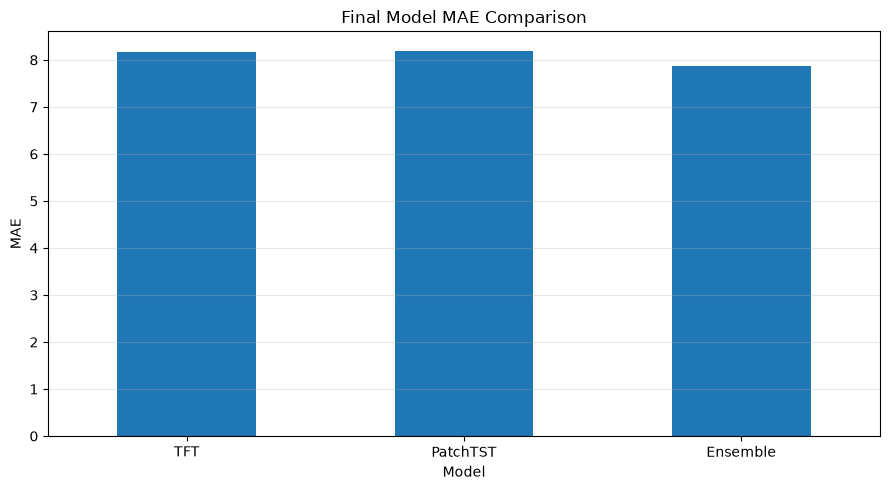

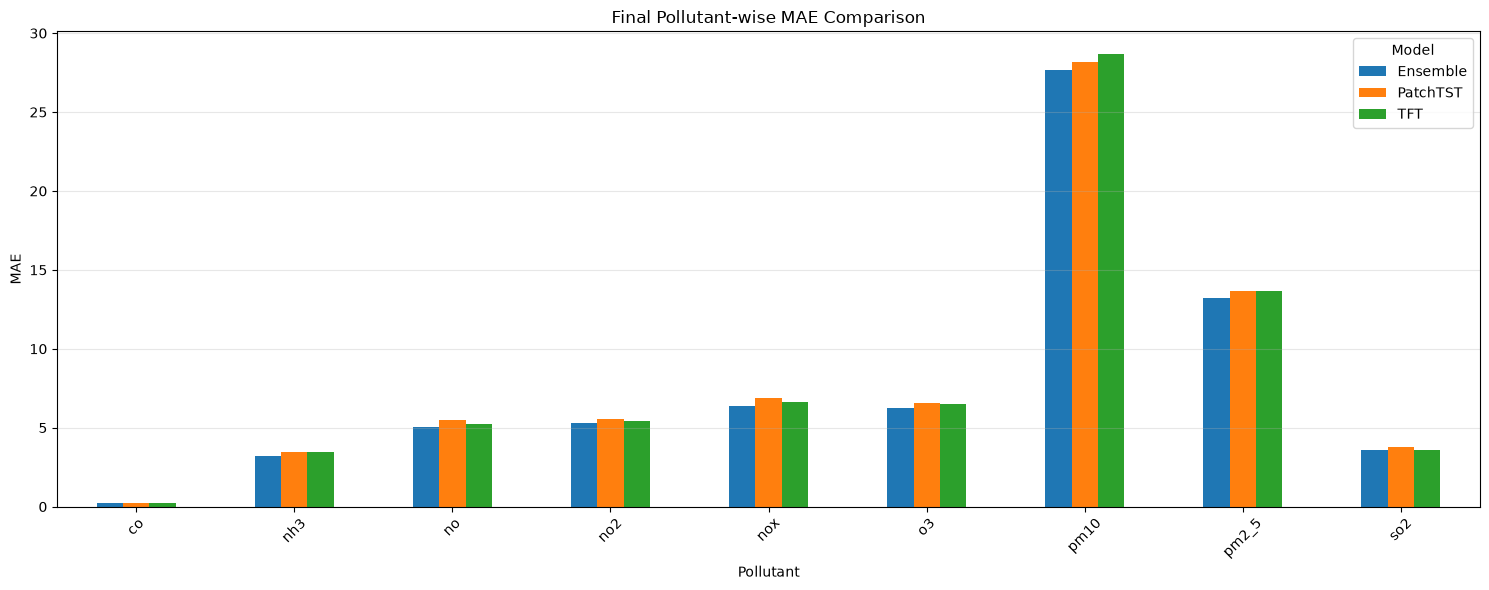

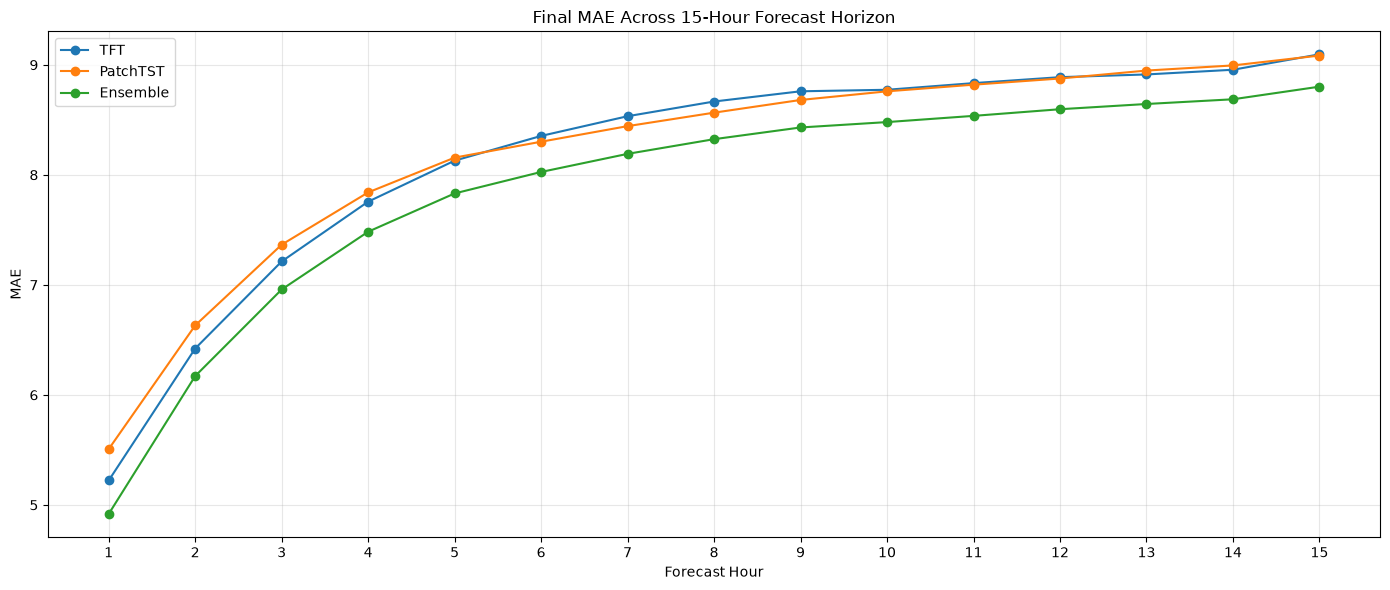

FINAL AIR QUALITY FORECASTING SUMMARY

Best MAE model   : Ensemble
Best MAE         : 7.8717
Best RMSE model  : Ensemble
Best R2 model    : Ensemble

Forecast horizon : 15 hours
Pollutants       : 9
Ensemble method  : equal-weight fallback

Final Ensemble Pollutant Metrics


,Pollutant,MAE,RMSE,R2,sMAPE
0,pm2_5,13.2053,29.9386,0.6851,28.8875
1,pm10,27.6733,51.9919,0.7085,26.9612
2,no,5.0479,16.5453,0.4889,42.4318
3,no2,5.2672,11.4813,0.7729,24.4938
4,nox,6.3798,16.6100,0.6413,27.9440
5,nh3,3.2055,8.4765,0.8102,15.0660
6,co,0.2095,0.4088,0.6363,52.5083
7,so2,3.5858,8.4863,0.6415,26.0137
8,o3,6.2712,12.6264,0.7764,29.8861



Saved Final Files
 - ../Models/ensemble_model.pkl
 - ../Results/ensemble_weights.csv
 - ../Results/final_model_metrics.csv
 - ../Results/final_pollutant_metrics.csv
 - ../Results/final_horizon_metrics.csv
 - ../Results/ensemble_predictions.npz

Ensemble modeling completed successfully.

AIR QUALITY FORECASTING PIPELINE COMPLETED.


In [3]:
# ============================================================
# Cell 3: Final Comparison and Project Summary
# ============================================================

# ============================================================
# Overall MAE Comparison
# ============================================================

plt.figure(
    figsize=(9, 5)
)

overall_results[
    "MAE"
].plot(
    kind="bar"
)

plt.title(
    "Final Model MAE Comparison"
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()
plt.show()


# ============================================================
# Pollutant-Wise MAE Comparison
# ============================================================

pollutant_mae = (
    pollutant_results
    .pivot(
        index="Pollutant",
        columns="Model",
        values="MAE",
    )
)

pollutant_mae.plot(
    kind="bar",
    figsize=(15, 6),
)

plt.title(
    "Final Pollutant-wise MAE Comparison"
)

plt.xlabel("Pollutant")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()
plt.show()


# ============================================================
# Forecast Horizon Comparison
# ============================================================

plt.figure(
    figsize=(14, 6)
)

for model_name in model_predictions:

    model_data = horizon_results[
        horizon_results["Model"]
        == model_name
    ]

    plt.plot(
        model_data["Forecast_Hour"],
        model_data["MAE"],
        marker="o",
        label=model_name,
    )


plt.title(
    "Final MAE Across 15-Hour Forecast Horizon"
)

plt.xlabel("Forecast Hour")
plt.ylabel("MAE")

plt.xticks(
    range(
        1,
        PREDICTION_LENGTH + 1,
    )
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Final Summary
# ============================================================

best_model = (
    overall_results[
        "MAE"
    ].idxmin()
)

best_mae = (
    overall_results
    .loc[
        best_model,
        "MAE",
    ]
)

best_rmse_model = (
    overall_results[
        "RMSE"
    ].idxmin()
)

best_r2_model = (
    overall_results[
        "R2"
    ].idxmax()
)


ensemble_pollutant_results = (
    pollutant_results[
        pollutant_results["Model"]
        == "Ensemble"
    ]
    .reset_index(drop=True)
)


print("=" * 65)
print("FINAL AIR QUALITY FORECASTING SUMMARY")
print("=" * 65)

print(
    f"\nBest MAE model   : "
    f"{best_model}"
)

print(
    f"Best MAE         : "
    f"{best_mae:.4f}"
)

print(
    f"Best RMSE model  : "
    f"{best_rmse_model}"
)

print(
    f"Best R2 model    : "
    f"{best_r2_model}"
)

print(
    f"\nForecast horizon : "
    f"{PREDICTION_LENGTH} hours"
)

print(
    f"Pollutants       : "
    f"{NUM_TARGETS}"
)

print(
    f"Ensemble method  : "
    f"{WEIGHT_SOURCE}"
)


print(
    "\nFinal Ensemble Pollutant Metrics"
)

display(
    ensemble_pollutant_results[
        [
            "Pollutant",
            "MAE",
            "RMSE",
            "R2",
            "sMAPE",
        ]
    ].round(4)
)


print("\nSaved Final Files")

final_files = [
    ENSEMBLE_MODEL_PATH,
    RESULTS_DIR
    / "ensemble_weights.csv",
    RESULTS_DIR
    / "final_model_metrics.csv",
    RESULTS_DIR
    / "final_pollutant_metrics.csv",
    RESULTS_DIR
    / "final_horizon_metrics.csv",
    RESULTS_DIR
    / "ensemble_predictions.npz",
]

for path in final_files:

    print(
        f" - {path}"
    )


print(
    "\nEnsemble modeling completed "
    "successfully."
)

print(
    "\nAIR QUALITY FORECASTING "
    "PIPELINE COMPLETED."
)